# Градиентный спуск (20 баллов)

In [1277]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

np.random.seed(1234)

## Основная часть (10 баллов)

__Задача 1.__ Рассмотрим квадратичную задачу оптимизации:

$$ \min_{x \in \mathbb{R}^d} \left[f(x) := \frac{1}{2} x^\top A x - b^\top x\right], $$

где $b \in \mathbb{R}^d$, $A \in \mathbb{S}_{++}^{d}$.

__а) (2 балла)__ Докажите, что для константы сильной выпуклости верно $\mu \leq \lambda_{\min}(A)$.

__Решение__
Найдем гессиан $f(x) = \frac{1}{2} \langle x, Ax \rangle - \langle b, x \rangle$
$$
df = \frac{1}{2}(\langle dx, Ax \rangle + \langle A^T x, dx \rangle) - \langle b, dc \rangle = \left/ A \in \mathbb{S}_{++}^d \right/ = \langle Ax-b, dx \rangle \\
d^2f = d\langle Ax-b, dx_1 \rangle = \langle Adx, dx_1 \rangle \Rightarrow \nabla^2 f = A
$$

Из критерия $\mu$-сильной выпуклости второго порядка получаем $A \succeq \mu I_d$, т.е. $\text{spec}(A - \mu I_d) \geq 0$. Тогда учитывая, что $\text{spec}(A - \mu I_d) = \text{spec}(A) - k$, получаем $\mu \leq \lambda_{min} (A)$, ч.т.д.

__б) (1 балла)__ Докажите, что для константы Липшица градиента верно $L \geq \lambda_{\max} (A)$.

__Решение__

В соответствии с замечанием C4.11 имеем 

$$
\mu I_d \preceq A \preceq LI_d
$$.

Тогда из правой части неравнства, пользуясь аналогичным рассуждением о спектре матриц $A$ и $A - LI_d$, получаем требуемое неравенство.

__в) (1.5 балла)__ Реализуйте функцию генерации квадратичной задачи по заданной размерности $d$ и константам сильной выпуклости $\mu$ и гладкости $L$. Для создания матрицы $A$ учтите, что ортогональные преобразования не изменяют собственные значения матрицы.

In [1278]:
def generate_quadratic_problem(d, mu, L):
    """
    Генерирует квадратичную оптимизационную задачу:
    min_x f(x) = 0.5 * x^\top A x — b^\top x

    Параметры:
        d (int): Размерность задачи
        mu (float): Константа сильной выпуклости (mu > 0)
        L (float): Константа гладкости (L > mu)

    Возвращает:
        A (np.array): Симметричная положительно определенная матрица размерности d x d
        b (np.array): Вектор размерности d
    """
    
    if mu <= 0 or L <= mu:
        raise ValueError("Условия mu > 0 и L > mu должны выполняться.")
    
    A = np.diag(np.linspace(mu, L, d))
    b = np.random.uniform(size=d)
    
    return A, b

In [1279]:
# Выполним проверку сгенерированной задачи при заданных параметрах
d = 50
mu = 1.0
L = 10.0

A, b = generate_quadratic_problem(d, mu, L)

# Проверка, что A симметрична
assert np.allclose(A, A.T), "Матрица A не симметрична."

# Проверка собственных значений A
eigenvalues_A = np.linalg.eigvalsh(A)
assert np.min(eigenvalues_A) >= mu - 10e-6, "Минимальное собственное значение A меньше mu."
assert np.max(eigenvalues_A) <= L + 10e-6, "Максимальное собственное значение A больше L."

__г) (0.5 балл)__ Докажите, что аналитическое решение квадратичной задачи имеет следующий вид:

$$ x^* = A^{-1}b.$$

__Решение__

Из пункта a $\nabla f = Ax-b$ и $\nabla^2 f = A \succeq 0$. Тогда

$$
\nabla f(x^*) = 0 \Rightarrow x^* = A^{-1}b - минимум
$$

Напишите код для вычисления $x^*$.

In [1280]:
# Ваше решение (Code)
def quadratic_problem_min(A, b): return np.linalg.inv(A) @ b

__Задача 2.__ В данной задаче мы рассмотрим поиск решения квадратичной задачи с помощью градиентного спуска.

__а) (0.5 балла)__ Реализуйте функцию подсчета градиента в заданной точке $x$ для функции $f(x)$.

In [1281]:
def grad(x, A, b):
    """
    Вычисляет градиент квадратичной функции f(x) = 0.5 * x^T A x — b^T x.

    Параметры:
        x (np.array): Точка, в которой вычисляется градиент
        A (np.array): Матрица квадратичной задачи
        b (np.array): Вектор линейной части

    Возвращает:
        grad (np.array): Градиент функции в точке x
    """

    return A@x-b

__б) (0.5 балла)__ Для оценки сходимости мы будем использовать следующий критерий: $\| x - x^* \|_2$. Реализуйте функцию для подсчета данного критерия.

In [1282]:
def criterion(x, x_star):
    """
    Вычисляет аргументный критерий сходимости: ||x - x*||_2.
    
    Параметры:
        x (np.array): Текущая точка
        x_star (np.array): Точное решение
    
    Возвращает:
        norm (float): Значение критерия
    """

    return np.sqrt((x-x_star) @ (x-x_star))

In [1283]:
x = np.random.uniform(size=3)
x_star = np.random.uniform(size=3)

assert np.allclose(criterion(x, x_star), np.linalg.norm(x-x_star))

__в) (4 балла)__  Реализуйте метод градиентного спуска.

**Псевдокод алгоритма**

---

_Инициализация:_

- Размер шага $\{ \gamma_k \}_{k=0} > 0$
- Начальная точка $x^0 \in \mathbb{R}^d$
- Максимальное число итераций $K$

---

$k$_-ая итерация:_

$$x^{k+1} = x^k - \gamma_k \nabla f \left(x^k\right)$$

---

_Условие остановки:_

- Достигнуто максимальное число итераций $K$ или $\| x^k - x^* \|_2 < \varepsilon$.

---

_Выход:_

- Полученное значение $x^K$.

In [1284]:
def gradient_descent(A, b, grad, criterion, x_0, x_star, eps=1e-6, max_iter=1000, **params):
    """
    Реализация градиентного спуска для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы
        b (np.array): Вектор линейной части
        grad (Callable): Функция для вычисления градиента
        criterion (Callable): Функция для вычисления критерия сходимости
        x_0 (np.array): Начальная точка
        x_star (np.array): Точное решение
        eps (float): Точность сходимости
        max_iter (int): Максимальное число итераций
        **params: Именованные гиперпараметры метода
                  params['gamma'](k) - значение шага на итерации k (возможно, зависящее от аргумента)

    Возвращает:
        x (np.array): Найденное решение
        errors (list): Список значений критерия сходимости на каждой итерации
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]
    
    for k in range(max_iter):

        gamma = params['gamma'](k)
        x = x - gamma*grad(x, A, b)

        error = criterion(x, x_star)
        errors.append(error)
        
        if error < eps:
            break
            
    return x, errors

Запустите градиентный спуск на $K = 10^3$ итераций с шагом $\gamma_k = \frac{1}{L}$ и начальной точкой $x^0 = 0$. Постройте сравнительный график зависимости точности метода $\|x^k - x^*\|_2$ и теоретической оценки от числа итераций.

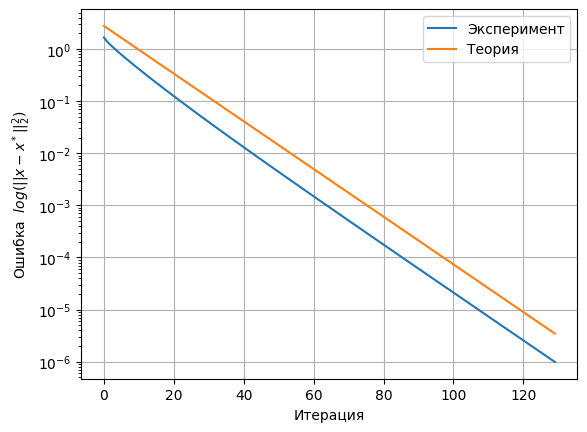

In [1285]:
# Ваше решение (Code)
A, b = generate_quadratic_problem(d, mu, L)
x_star = quadratic_problem_min(A, b)
x_0 = np.zeros(d)

step = lambda x: 1/L
def theory(mu, L, iter, x_0, x_star): return np.power((1-mu/L), iter)*criterion(x_0, x_star)**2

x, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=step)
iters = np.arange(len(errors))

plt.plot(iters, errors, label="Эксперимент")
plt.plot(iters, theory(mu, L, iters, x_0, x_star), label="Теория")
plt.ylabel(r"Ошибка $\ log(||x - x^*||_2^2$)")
plt.xlabel("Итерация")
plt.yscale("log")
plt.grid()
plt.legend()

## Дополнительная часть (10 баллов)

__Задача 3.__ Рассмотрим различные значения $\gamma_k$ и их влияние на сходимость градиентного спуска.

__а) (1 балл)__ Рассмотрите следующие значения шага:

1. $\gamma_k = \frac{1}{2L}$;

2. $\gamma_k = \frac{1}{L}$;

3. $\gamma_k = \frac{2}{L}$;

4. $\gamma_k = \frac{3}{L}$;

5. $\gamma_k = \frac{2}{\mu + L}$.

Проверьте, при каких значениях алгоритм сходится к решению. Нанесите на график те запуски, при которых наблюдается сходимость (теоретическую сходимость можно убрать).

In [1286]:
# Ваше решение (Code)

max_iter = 200
def plot_for_steps(A, b, grad, criterion, x_0, x_star, gammas, ks):

    for d, gamma in enumerate(gammas):

        x, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma)
        iters = np.arange(len(errors))

        plt.plot(iters[:max_iter], errors[:max_iter], label=fr"$\gamma_k$ = {ks[d]}" + r"$\frac{1}{L}$")

    plt.ylabel("Ошибка (log)")
    plt.xlabel("Итерация")
    plt.grid()

/tmp/ipykernel_658378/3861606337.py:13: RuntimeWarning: overflow encountered in matmul
  return np.sqrt((x-x_star) @ (x-x_star))


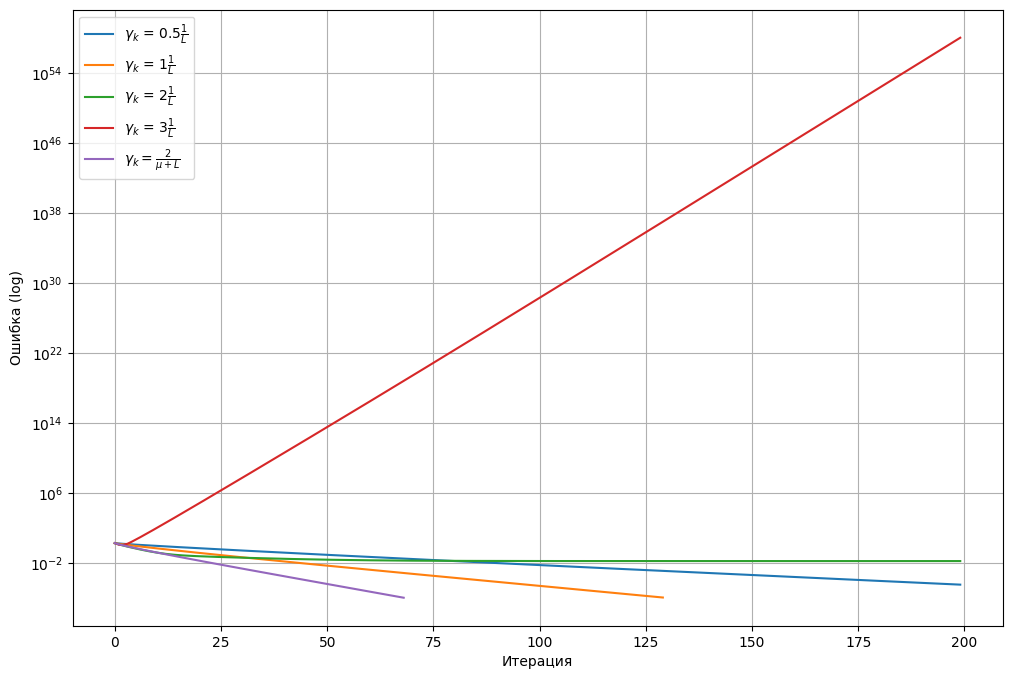

In [1287]:
ks = [1/2, 1, 2, 3]
gammas = [lambda x, k=k: k*1/L for k in ks]

plt.figure(figsize=(12, 8))
plot_for_steps(A, b, grad, criterion, x_0, x_star, gammas, ks)

x, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=lambda x: 2/(mu+L))
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label=r"$\gamma_k = \frac{2}{\mu + L}$")

plt.yscale("log")
plt.legend()

На каком шаге получен наибыстрейший результат? Как думаете, почему?

__Решение__

См. последний пункт с общий сравнением

__б) (2.5 балла)__ Рассмотрим значение шага $\gamma_k = \arg\min\limits_{\gamma} f \left(x^k - \gamma \nabla f \left(x^k\right) \right)$. Такая модификация называется методом наискорейшего спуска. Докажите, что 
$$
\gamma_k  = \frac{\langle \nabla f(x^k), \nabla f(x^k) \rangle}{\langle A \nabla f(x^k), \nabla f(x^k) \rangle} .
$$

In [1288]:
# Ваше решение (Markdown)

__в) (2.5 балла)__ Реализуйте метод наискорейшего градиентного спуска. Для удобства предлагается немного изменить функцию градиентного спуска.

In [1289]:
def fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, eps=1e-6, max_iter=1000, **params):
    """
    Реализация наискорейшего градиентного спуска для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы
        b (np.array): Вектор линейной части
        grad (Callable): Функция для вычисления градиента
        criterion (Callable): Функция для вычисления критерия сходимости
        x_0 (np.array): Начальная точка
        x_star (np.array): Точное решение
        eps (float): Точность сходимости 
        max_iter (int): Максимальное число итераций
        **params: Именованные гиперпараметры метода
                params['gamma'](A, b, grad, x, x_star): значение шага на итерации k

    Возвращает:
        x (np.array): Найденное решение
        errors (list): Список значений критерия сходимости на каждой итерации
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]
    
    for k in range(max_iter):
        
        gamma = params['gamma'](A, b, grad, x, x_star)
        x = x - gamma*grad(x, A, b)

        error = criterion(x, x_star)
        errors.append(error)
        
        if error < eps:
            break
            
    return x, errors

In [1290]:
def gamma_fastest(A, b, grad, x, x_star):
    """
    Вычисляет шаг gamma_k = argmin f(x^k — gamma * ∇f(x_k))

    Параметры:
        A (np.array): Матрица квадратичной формы
        b (np.array): Вектор линейной части
        grad (Callable): Функция для вычисления градиента
        x (np.array): Точка
        x_star (np.array): Точное решение

    Возвращает:
        gamma (float): Найденное решение
    """
    
    gamma_k = (grad(x, A, b) @ grad(x, A, b)) / ((A @ grad(x, A, b)) @ grad(x, A, b))

    return gamma_k

Запустите метод и сравните его с лучшим результатом, полученными для постоянного шага.

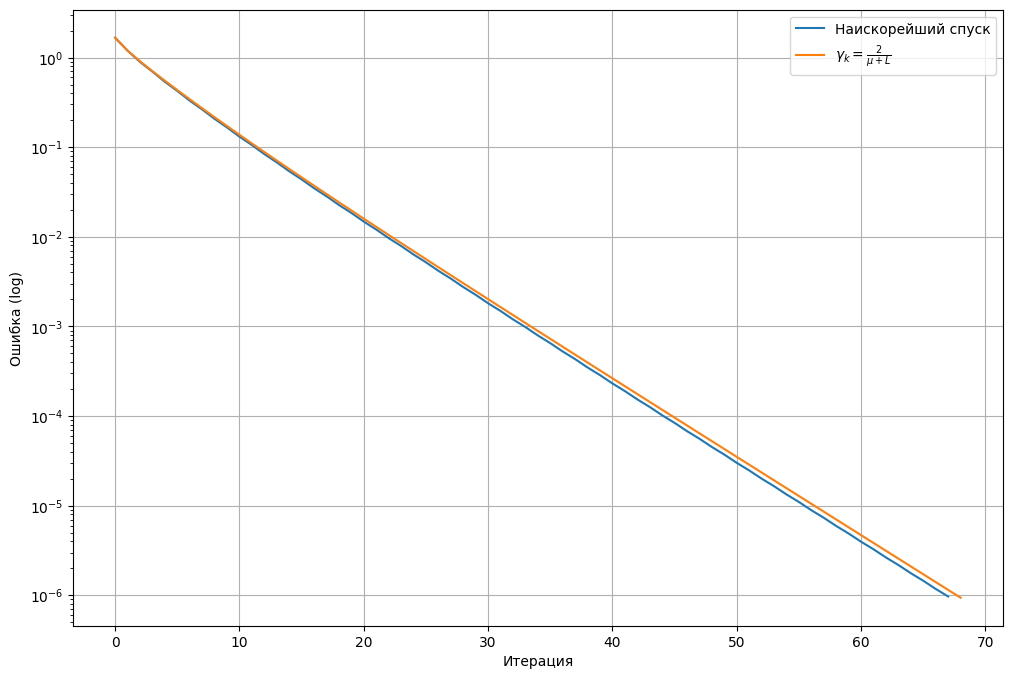

In [1291]:
# Ваше решение (Code)
max_iter = 200
plt.figure(figsize=(12, 8))

x, errors = fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_fastest)
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label="Наискорейший спуск")

x, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=lambda x: 2/(mu+L))
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label=r"$\gamma_k = \frac{2}{\mu + L}$")

plt.ylabel("Ошибка (log)")
plt.xlabel("Итерация")
plt.grid()
plt.legend()
plt.yscale("log")

__г) (2 балла)__ И последним способом подбора шага станет шаг Поляка—Шора: $\gamma_k = \frac{f \left(x^k\right) - f^*}{\alpha \|\nabla f\left(x^k\right)\|^2_2}$, где $\alpha$ нужно подобрать отдельно.

In [1292]:
def schor_gradient_descent(A, b, grad, criterion, x_0, x_star, eps=1e-6, max_iter=1000, **params):
    """
    Реализация градиентного спуска с шагом Поляка—Шора для квадратичной задачи.

    Параметры:
        A (np.array): Матрица квадратичной формы
        b (np.array): Вектор линейной части
        grad (Callable): Функция для вычисления градиента
        criterion (Callable): Функция для вычисления критерия сходимости
        x_0 (np.array): Начальная точка
        x_star (np.array): Точное решение
        eps (float): Точность сходимости
        max_iter (int): Максимальное число итераций
        **params: Именованные гиперпараметры метода
            params['gamma'](A, b, grad, x, x_star, alpha): значение шага на итерации k
            params['alpha']: параметр шага Поляка—Шора

    Возвращает:
        x (np.array): Найденное решение
        errors (list): Список значений критерия сходимости на каждой итерации
    """
    x = x_0.copy()
    errors = [criterion(x, x_star)]

    alpha = params['alpha']
    
    for k in range(max_iter):
        
        gamma = params['gamma'](A, b, grad, x, x_star, alpha)
        x = x - gamma*grad(x, A, b)

        error = criterion(x, x_star)
        errors.append(error)
        
        if error < eps:
            break
            
    return x, errors

In [1293]:
def gamma_schor(A, b, grad, x, x_star, alpha):
    """
    Вычисляет шаг gamma_k = (f(x^k) - f(x^*))/(alpha||∇f(x^k)||_2^2).

    Параметры:
        A (np.array): Матрица квадратичной формы
        b (np.array): Вектор линейной части
        grad (Callable): Функция для вычисления градиента
        x (np.array): Точка
        x_star (np.array): Точное решение
        alpha (float): Параметр шага Поляка—Шора

    Возвращает:
        gamma (float): Найденное решение
    """
    
    def f(x): return 1/2*x.T @ A @ x - b.T @ x
    gamma_k = (f(x) - f(x_star))/(alpha*np.linalg.norm(grad(x, A, b))**2)

    return gamma_k

Рассмотрите следующие значения для $\alpha$: 0.8, 1.0, 1.2, 1.5 и 2.0. Постройте сравнительные графики, найдите значение $\alpha$, при котором достигается наилучшая сходимость.

In [1294]:
# Ваше решение (Code)

def plot_for_alphas(A, b, grad, criterion, x_0, x_star, alphas):

    for alpha in alphas:

        x, errors = schor_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_schor, alpha=alpha)
        iters = np.arange(len(errors))

        plt.plot(iters[:max_iter], errors[:max_iter], label=fr"$\alpha$ = {alpha}")

    plt.ylabel("Ошибка (log)")
    plt.xlabel("Итерация")
    plt.grid()

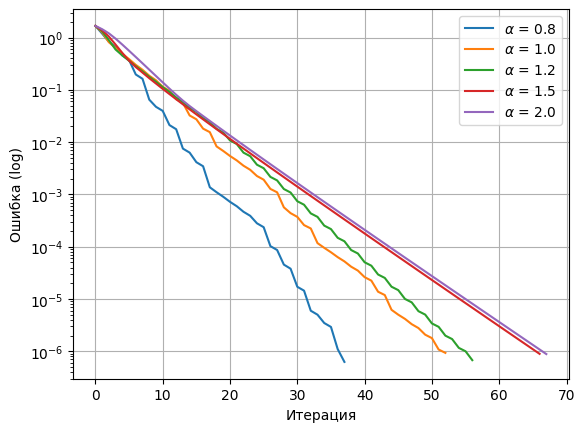

In [1295]:
alphas = (0.8, 1.0, 1.2, 1.5, 2.0)
plot_for_alphas(A, b, grad, criterion, x_0, x_star, alphas)

plt.legend()
plt.yscale("log")

__д) (2 балла)__ Финал — постройте итоговый сравнительный график, на котором должны быть лучшие представители для

1. Постоянного шага;

2. Шага наискорейшего спуска;

3. Шага Поляка—Шора.

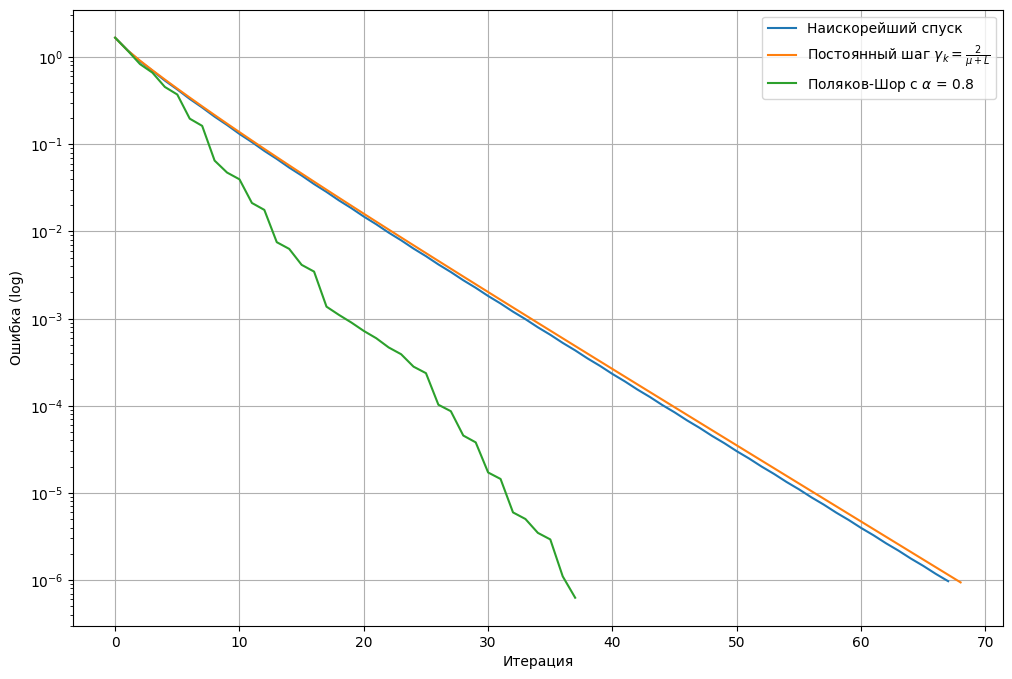

In [1296]:
# Ваше решение (Code)

max_iter = 200
plt.figure(figsize=(12, 8))

x, errors = fastest_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_fastest)
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label="Наискорейший спуск")

x, errors = gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=lambda x: 2/(mu+L))
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label=r"Постоянный шаг $\gamma_k = \frac{2}{\mu + L}$")

x, errors = schor_gradient_descent(A, b, grad, criterion, x_0, x_star, gamma=gamma_schor, alpha=0.8)
iters = np.arange(len(errors))
plt.plot(iters[:max_iter], errors[:max_iter], label=fr"Поляков-Шор с $\alpha$ = {0.8}")

plt.ylabel("Ошибка (log)")
plt.xlabel("Итерация")
plt.grid()
plt.legend()
plt.yscale("log")

Объясните полученные результаты. 

__Решение__

Видим что лучше всех работает шаг Полякова-Шора, а наискорейший спуск примерно совпал с постоянным шагом. Первое совпадает с теорией, второе вероятно является удачным совпадением. Данный постоянный шаг минимизирует (или почти минимизирует) спектральный радиус невязки, что позволяет ему сходится быстрее других постоянных шагов и наравне с наискорейшим спуском.